In [8]:
from sklearn.cluster import KMeans
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

In [9]:
#Load Data
data = pd.read_csv('D:/Learn with me (DS and AIML)/actual.csv')
data.head()

,patient,cancer
0,1,ALL
1,2,ALL
2,3,ALL
3,4,ALL
4,5,ALL


In [10]:
#Defining the columns
num = ['patient']
cancer = ['cancer']
#Creating the preprocessor steps
preprocessor = ColumnTransformer(
    transformers=[
        ('num', 'passthrough', num),
        ('cat', OneHotEncoder(handle_unknown='ignore'), cancer)
    ]
)
data_transformed = preprocessor.fit_transform(data)

In [11]:
#Model finds group automatically
model = KMeans(n_clusters=2)
model.fit(data_transformed)

,n_clusters,2
,init,'k-means++'
,n_init,'auto'
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,None
,copy_x,True
,algorithm,'lloyd'


In [12]:
#Get cluster assignments
clusters = model.predict(data_transformed)
print(clusters)
data['cluster'] = clusters


[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]


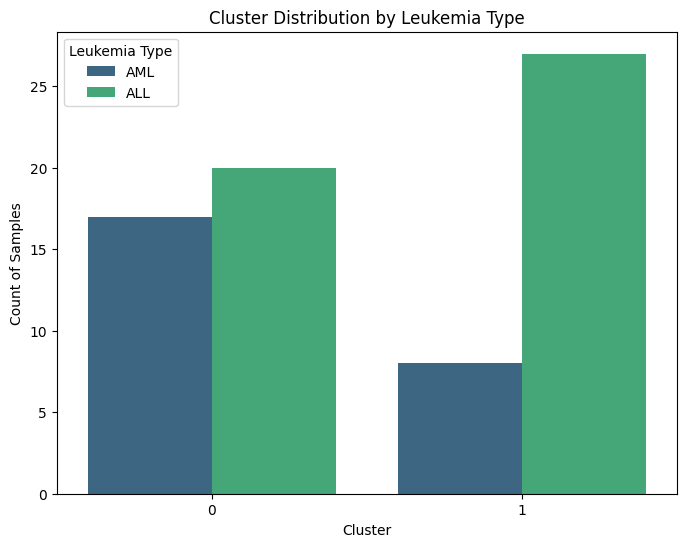

In [15]:
#Bar chart to show cluster distribution per cancer type..
plt.figure(figsize=(8,6))
sns.countplot(x='cluster', hue = 'cancer', data=data, palette='viridis')
plt.title('Cluster Distribution by Leukemia Type')
plt.xlabel('Cluster')
plt.ylabel('Count of Samples')
plt.legend(title='Leukemia Type')
plt.show()